Dataset Shape: (114000, 21)

Columns:
 Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

Missing Values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


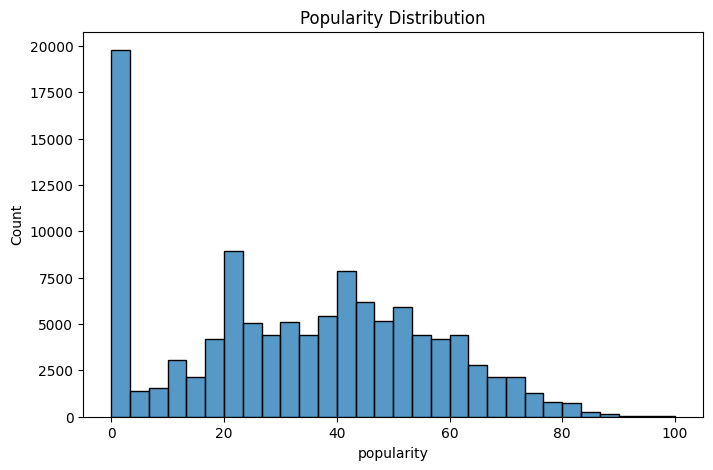

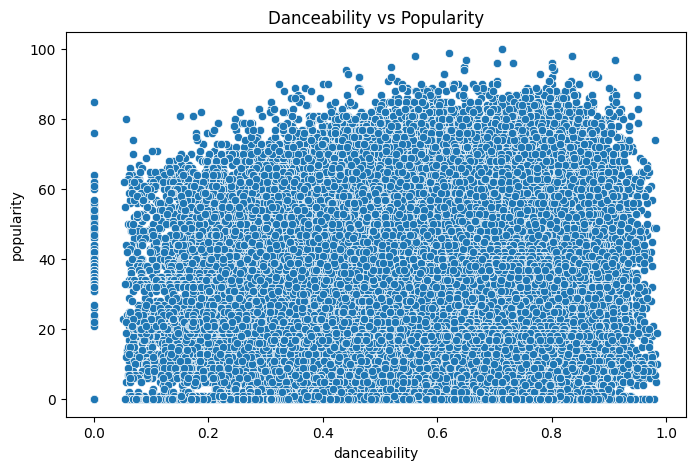

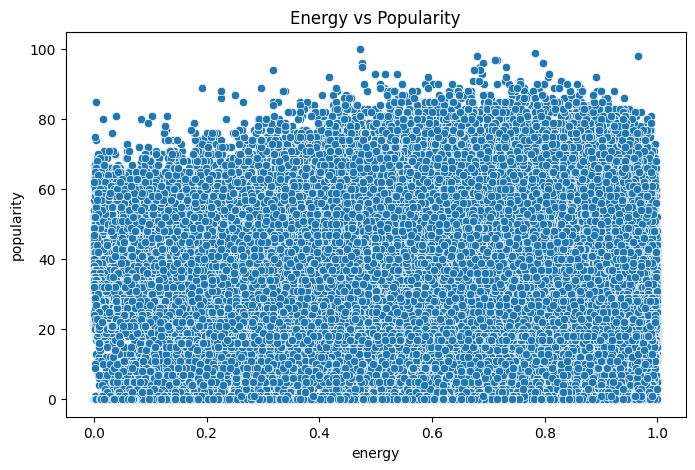

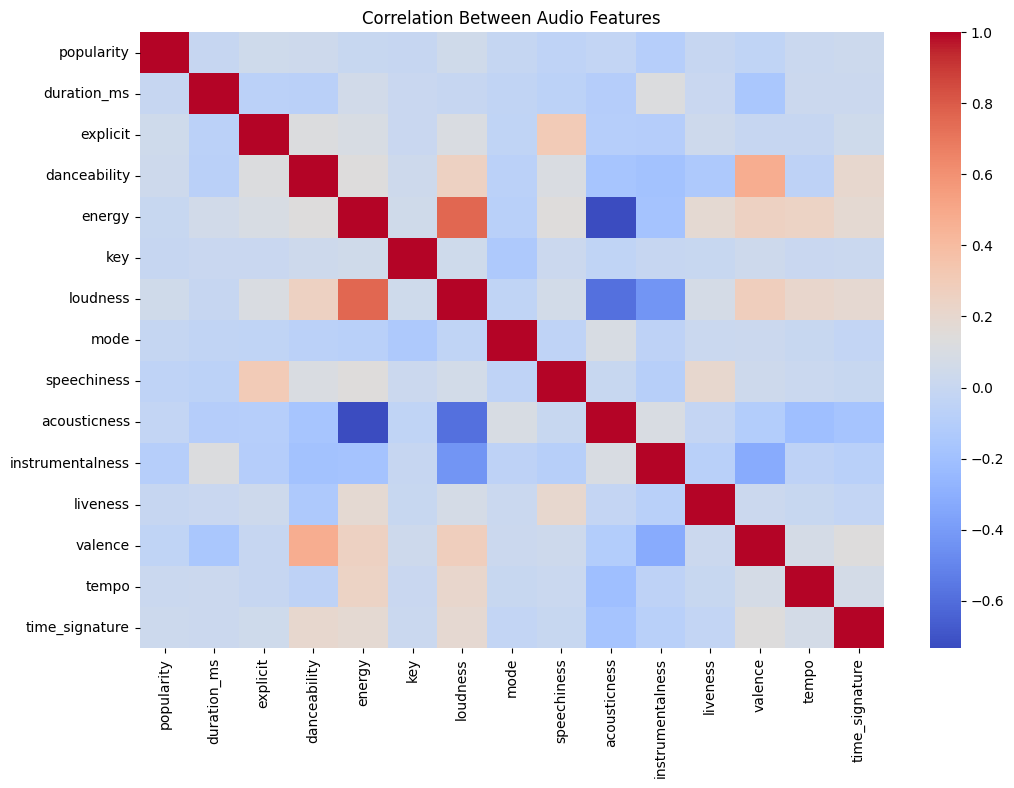


Model Performance
Mean Squared Error: 219.54374049466588
R2 Score: 0.5551119667495571


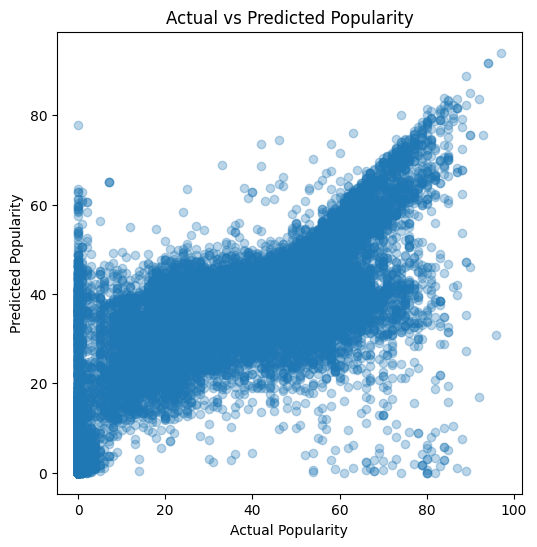

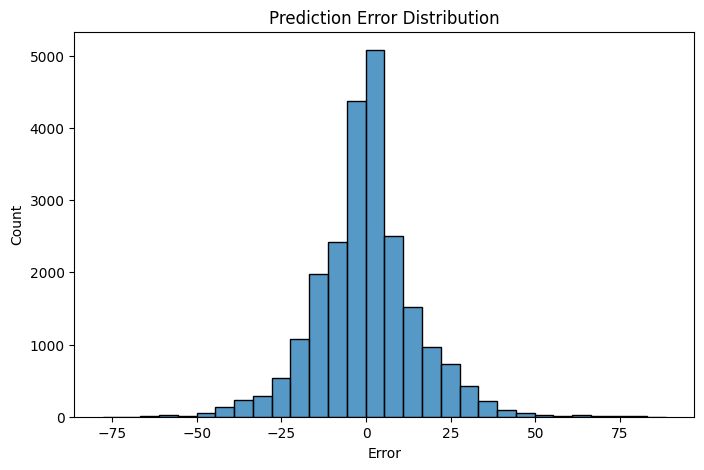

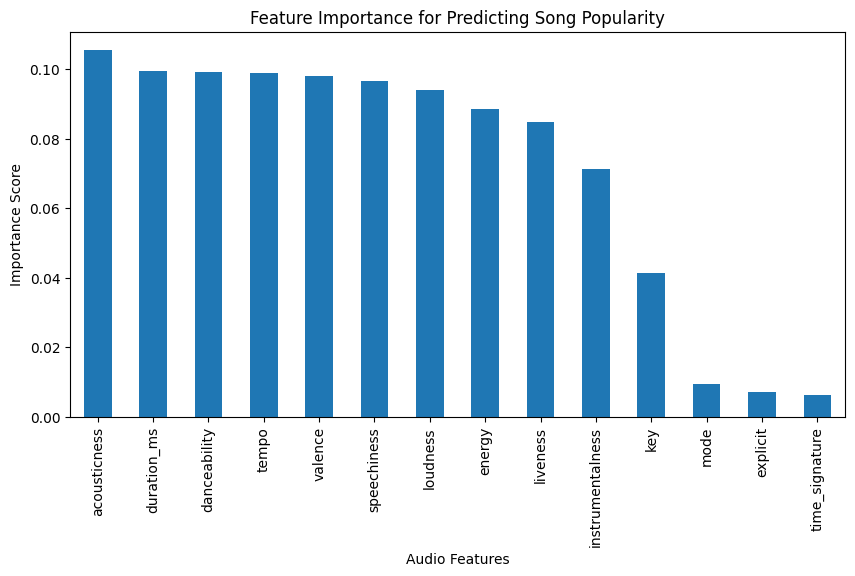

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# LOAD DATASET
# =========================
df = pd.read_csv("dataset.csv")

# =========================
# BASIC DATA EXPLORATION
# =========================
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nMissing Values:\n", df.isnull().sum())

# =========================
# DATA CLEANING
# =========================
# Remove duplicate rows
df = df.drop_duplicates()

# Drop unnecessary text columns that cannot be used in ML
df_ml = df.drop(columns=['Unnamed: 0','track_id','artists','album_name','track_name','track_genre'])

# Convert boolean column into numeric
df_ml['explicit'] = df_ml['explicit'].astype(int)

# =========================
# EDA VISUALIZATIONS
# =========================

# Popularity distribution
plt.figure(figsize=(8,5))
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

# Danceability vs Popularity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['danceability'], y=df['popularity'])
plt.title("Danceability vs Popularity")
plt.show()

# Energy vs Popularity
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['energy'], y=df['popularity'])
plt.title("Energy vs Popularity")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df_ml.corr(), cmap="coolwarm")
plt.title("Correlation Between Audio Features")
plt.show()

# =========================
# MACHINE LEARNING
# =========================

# Define features and target
X = df_ml.drop('popularity', axis=1)
y = df_ml['popularity']

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict popularity
y_pred = model.predict(X_test)

# =========================
# MODEL EVALUATION
# =========================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# =========================
# ML VISUALIZATIONS
# =========================

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted Popularity")
plt.show()

# Prediction Error Distribution
errors = y_test - y_pred
plt.figure(figsize=(8,5))
sns.histplot(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

# Feature Importance
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)

plt.figure(figsize=(10,5))
feature_importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance for Predicting Song Popularity")
plt.xlabel("Audio Features")
plt.ylabel("Importance Score")
plt.show()